<center><h1>Vikraman_Madhulika_HW2</h1></center>
<br>
<br>

<h1>DSCI 552 Homework 1</h1>

Name: Madhulika Vikraman
<br>
Github Username: madhulikavikraman
<br>
USC ID: 2083047114

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics.pairwise import euclidean_distances
import statistics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel("../data/Folds5x2_pp.xlsx", engine='openpyxl')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print("Number of rows in the dataset: " + str(df.shape[0]))
print("Number of columns in the dataset: " + str(df.shape[1]))

Number of rows in the dataset: 9568
Number of columns in the dataset: 5


The rows represent the set of values {Temperature, Ambient Pressure, Relative Humidity, Exhaust Vacuum} (independent variables xi) that result in Net energy output (dependent variable y).

The columns refers to dependent factors and independent factors in the task. 

#### ii. pairwise scatterplots of all the variables

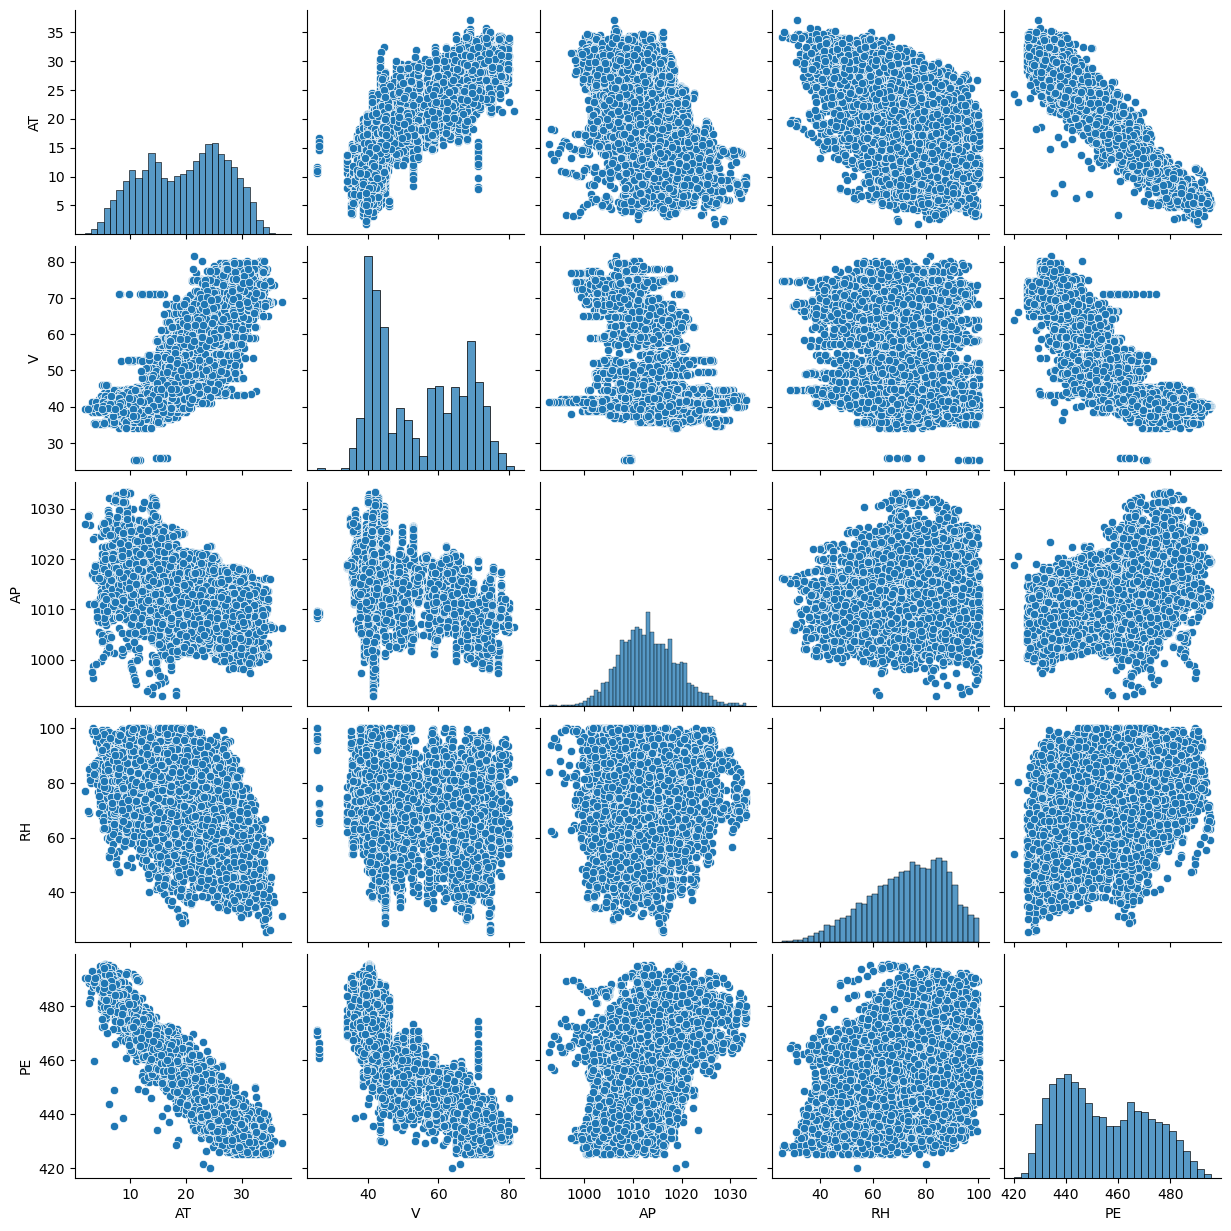

In [4]:
sns.pairplot(df)
plt.show()

A pairplot is a matrix of scatterplots between all combinations of two variables in a dataset.
The diagonal elements are histograms showing the distribution of a single variable and the other scatter plots are relationships between 2 different variables.

PE vs RH and PE vs AP are more scattered and thus have less correlation, whereas PE vs AT and PE vs V are tighter showing higher degree of correlation. 

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
des = df.describe()
des.loc['median'] = df.median()
des.loc['range'] = df.max() - df.min()
des.loc["IQR"] = df.quantile(0.75) - df.quantile(0.25)
print(des)

                 AT            V           AP           RH           PE
count   9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean      19.651231    54.305804  1013.259078    73.308978   454.365009
std        7.452473    12.707893     5.938784    14.600269    17.066995
min        1.810000    25.360000   992.890000    25.560000   420.260000
25%       13.510000    41.740000  1009.100000    63.327500   439.750000
50%       20.345000    52.080000  1012.940000    74.975000   451.550000
75%       25.720000    66.540000  1017.260000    84.830000   468.430000
max       37.110000    81.560000  1033.300000   100.160000   495.760000
median    20.345000    52.080000  1012.940000    74.975000   451.550000
range     35.300000    56.200000    40.410000    74.600000    75.500000
IQR       12.210000    24.800000     8.160000    21.502500    28.680000


### (c) Simple Linear Regression

In [6]:
final_testing_error_d = {}


Running regression: PE ~ AT

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:45:22   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341 

C:\Users\madhu\AppData\Local\Temp\ipykernel_8908\343180552.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lin_reg_params.append((col, model_no_outliers.params[1]))


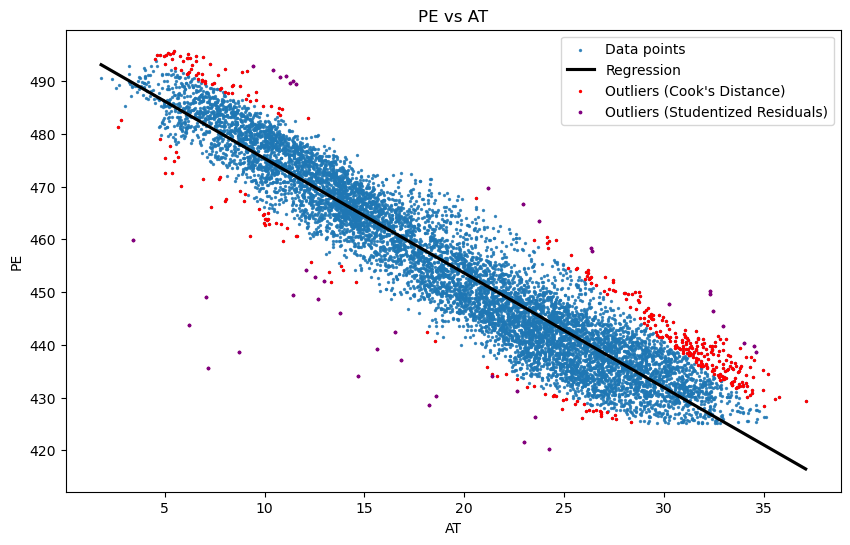

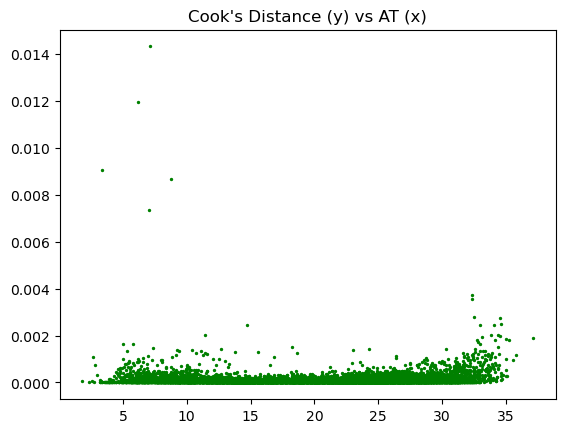


Running regression: PE ~ V

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:45:43   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015  

C:\Users\madhu\AppData\Local\Temp\ipykernel_8908\343180552.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lin_reg_params.append((col, model_no_outliers.params[1]))


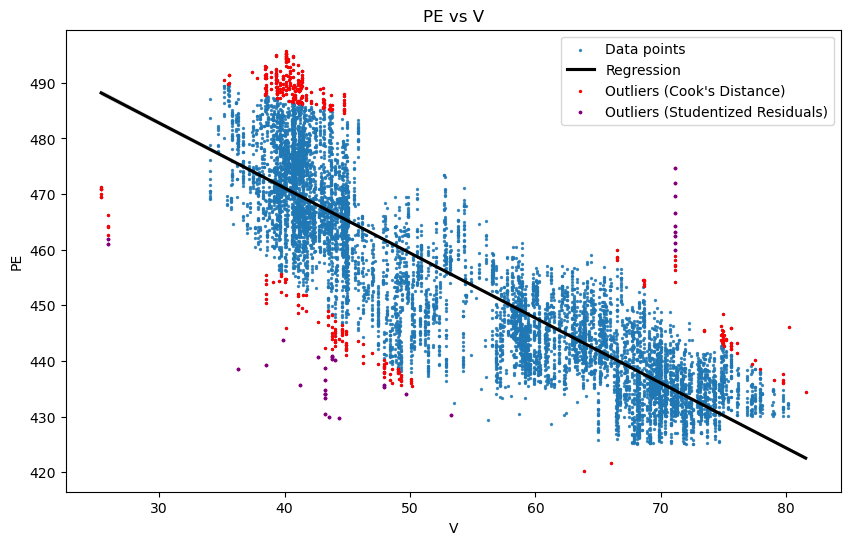

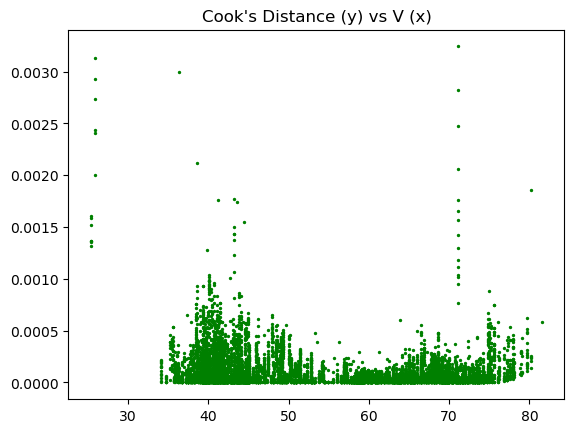


Running regression: PE ~ AP

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:06   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610 

C:\Users\madhu\AppData\Local\Temp\ipykernel_8908\343180552.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lin_reg_params.append((col, model_no_outliers.params[1]))


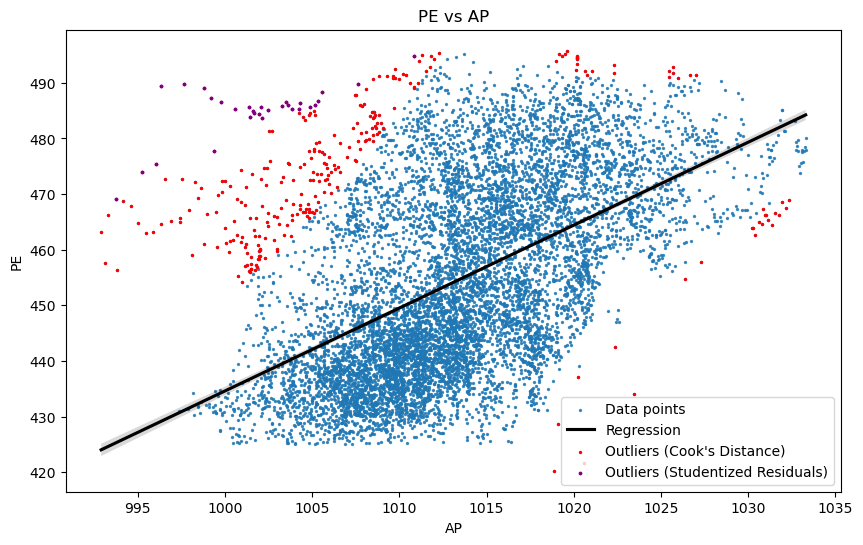

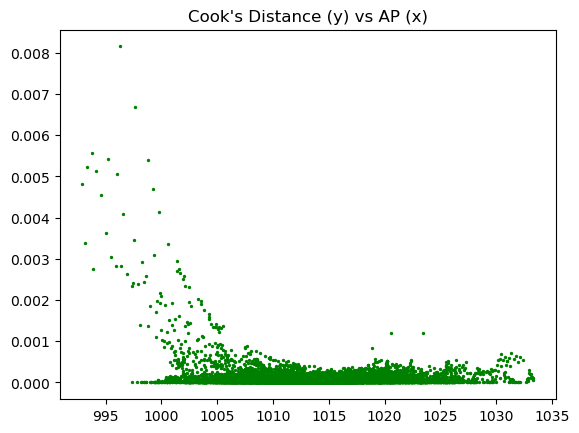


Running regression: PE ~ RH

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:31   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    420.9618 

C:\Users\madhu\AppData\Local\Temp\ipykernel_8908\343180552.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lin_reg_params.append((col, model_no_outliers.params[1]))


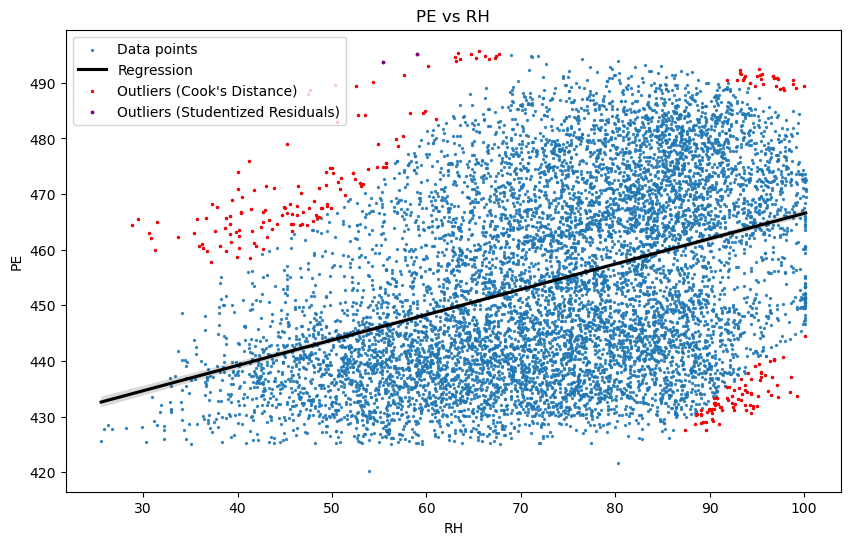

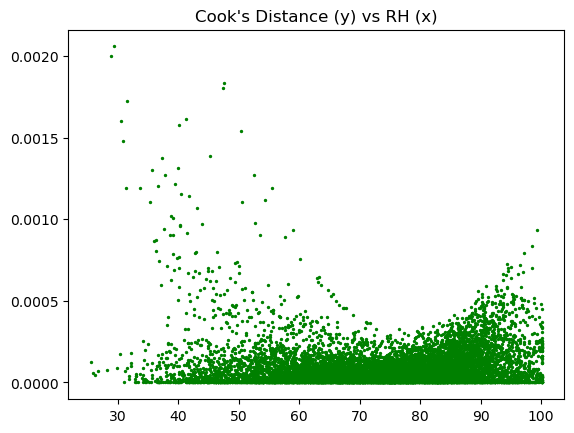


The regression of PE on AT is statistically significant.

R-squared for AT before removing outliers: 0.8989
R-squared for AT after removing outliers: 0.9196

The regression of PE on V is statistically significant.

R-squared for V before removing outliers: 0.7565
R-squared for V after removing outliers: 0.7980

The regression of PE on AP is statistically significant.

R-squared for AP before removing outliers: 0.2688
R-squared for AP after removing outliers: 0.3610

The regression of PE on RH is statistically significant.

R-squared for RH before removing outliers: 0.1519
R-squared for RH after removing outliers: 0.1964



In [7]:

df1 = df.copy()
dftrain = df1.drop(columns=['PE'])
cols = ['AT', 'V', 'AP', 'RH']
s = ''
lin_reg_params = []
def simple_regressions(df, col, s):
    print(f"\nRunning regression: PE ~ {col}\n")
    model = smf.ols(formula=f'PE ~ {col}', data=df).fit()
    r2_original = model.rsquared

    plt.figure(figsize=(10, 6))
    sns.regplot(x=col, y='PE', data=df, line_kws={"color": "black", "label": "Regression"}, scatter_kws={'s': 2}, label='Data points')
    plt.title(f"PE vs {col}")
    plt.xlabel(f'{col}')
    plt.ylabel('PE')
    print(model.summary())
    if model.pvalues.iloc[1] < 0.05:
        print(model.params[1:].index[0])
        s += f"\nThe regression of PE on {col} is statistically significant.\n"
    else:
        print(model.params[1:].index[0])
        s += f"\nThe regression of PE on {col} is NOT statistically significant.\n"

    influence = model.get_influence()
    cooks_dist = influence.cooks_distance[0]
    cooks_pts = np.where(cooks_dist > 4 / len(df))[0]
    if len(cooks_pts) > 0:
        plt.scatter(df[col].iloc[cooks_pts], df['PE'].iloc[cooks_pts], color='red', label='Outliers (Cook\'s Distance)', s=2)


    student_resid = influence.resid_studentized_external
    student_pts = np.where(np.abs(student_resid) > 3)[0]

    remove_idx = np.union1d(cooks_pts, student_pts) # try removing outliers from both distances
    df_no_outliers = df.drop(index=remove_idx)
    model_no_outliers = smf.ols(formula=f'PE ~ {col}', data=df_no_outliers).fit()
    r2_clean = model_no_outliers.rsquared
    
    s+=f"\nR-squared for {col} before removing outliers: {r2_original:.4f}\n"
    s+=f"R-squared for {col} after removing outliers: {r2_clean:.4f}\n"
    lin_reg_params.append((col, model_no_outliers.params[1]))
    plt.scatter(df[col].iloc[student_pts], df['PE'].iloc[student_pts], color='purple', label='Outliers (Studentized Residuals)', s=3)
    plt.legend()
    plt.show()
    plt.scatter(dftrain[col], cooks_dist, color='green', label='Cooks Distance', s=2)
    plt.title(f"Cook's Distance (y) vs {col} (x)")
    plt.show()
    return s
for col in cols:
    s = simple_regressions(df1, col, s)
print(s)


Since the p-value is 0.000 in all cases, all the predictors are statisticlly significant. Outliers can be found through cook's distance and studentized residuals. 


After removing the combined 'outlier' points that have high Cook's distance or Studentized residual, the R squared values increased slightly. This proves that the points removed were outliers.

### (d) Multiple Regression

In [8]:
response = 'PE'
predictors = ['AT', 'V', 'AP', 'RH']
multi_reg_params = []
formula = response + ' ~ ' + ' + '.join(predictors)
model_full = smf.ols(formula=formula, data=df).fit()
multi_reg_params.append(list(zip(predictors, model_full.params[1:].values)))
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:52   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

All the p values are 0.000 for the predictors, so if p-value is < 0.05 it is statistically significant and we can reject the null hypothesis H0 for all of them.

### (e) 1c Compare to 1d

In [9]:
print(list(lin_reg_params))
print(list(multi_reg_params[0]))
df2 = pd.DataFrame({'Univariate_coefficient': list(lin_reg_params), 'Multivariate_coefficient': list(multi_reg_params[0])})

[('AT', -2.233630424958739), ('V', -1.166625574079518), ('AP', 1.764806787111363), ('RH', 0.5251615232875977)]
[('AT', -1.9775131066353921), ('V', -0.2339164225824993), ('AP', 0.062082943780854716), ('RH', -0.15805410291640945)]


,Univariate_coefficient,Multivariate_coefficient
Predictor,,
AT,-2.233630,-1.977513
V,-1.166626,-0.233916
AP,1.764807,0.062083
RH,0.525162,-0.158054


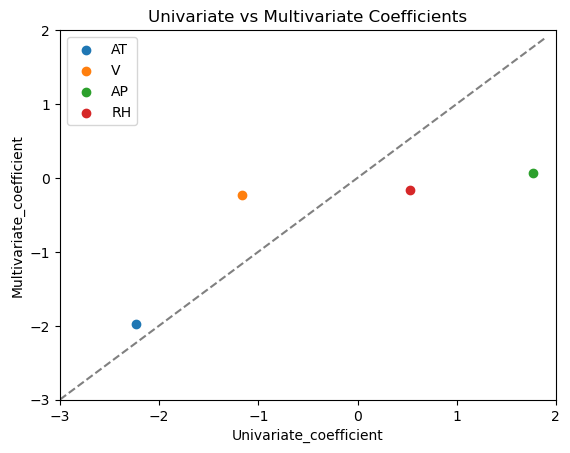

In [10]:
df2 = pd.DataFrame({'Predictor': [x[0] for x in lin_reg_params], 'Univariate_coefficient': [x[1] for x in lin_reg_params], 'Multivariate_coefficient': [x[1] for x in multi_reg_params[0]]})
df2 = df2.set_index('Predictor')
display(df2)
for predictor in df2.index:
    plt.scatter(df2.loc[predictor, 'Univariate_coefficient'], df2.loc[predictor, 'Multivariate_coefficient'], label=predictor)
plt.xlabel("Univariate_coefficient")
plt.ylabel("Multivariate_coefficient")
plt.xlim(-3, 2)
plt.ylim(-3, 2)
plt.plot(np.arange(-3, 2, 0.1), np.arange(-3, 2, 0.1), color='gray', linestyle='--')  
plt.title("Univariate vs Multivariate Coefficients")
plt.legend()
plt.show()

We can see that AT has univariate and multivariate coefficients most similar to each other while AP has least similar ones.

The points to the left of the diagonal have higher multivariate coefficent and the points on the right have higher univariate coefficient.

### (f) Nonlinear Association

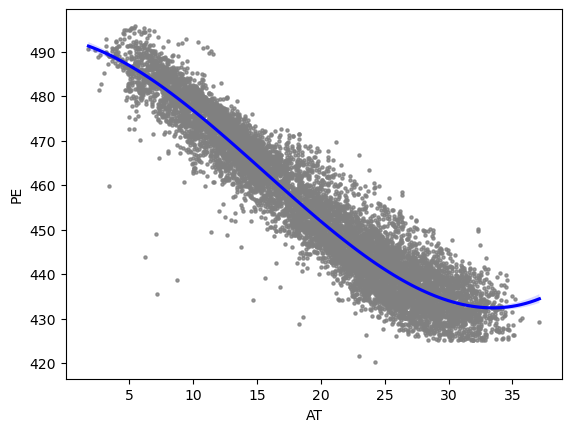

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:54   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.0

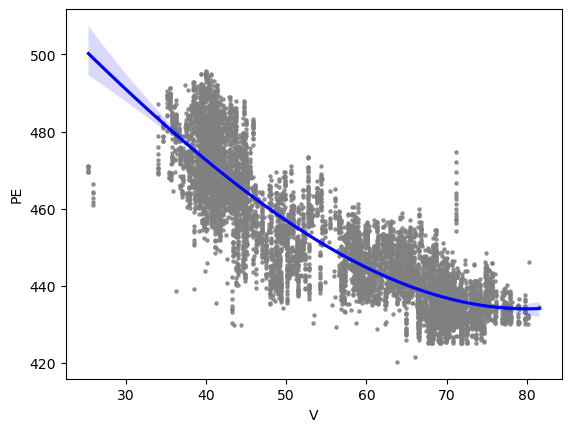

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:55   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    554.1468      9.151     60.557      0.0

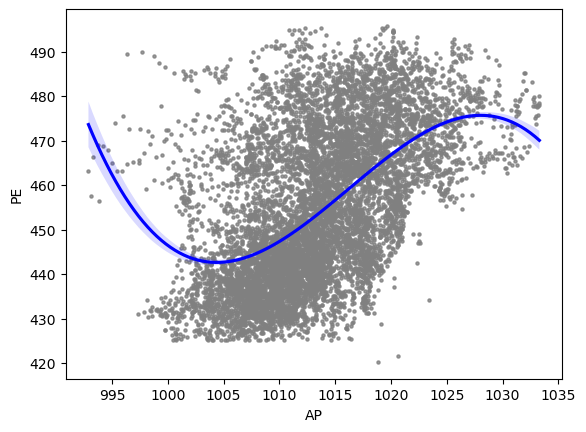

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:56   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0747      0.009      8.415      0.0

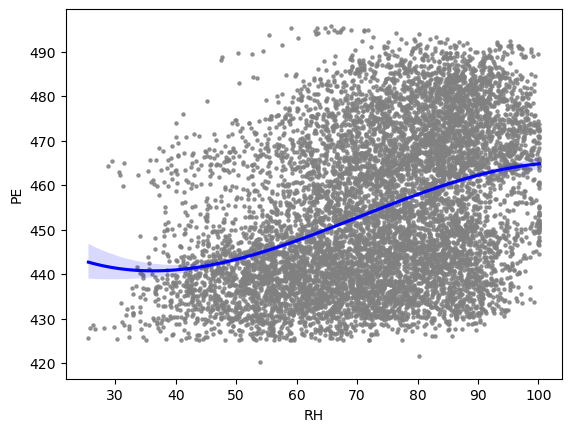

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:58   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    468.4135     10.545     44.422      0.0

In [11]:
df1 = df.copy()
def non_lin_model(df, col):
    formula = f'PE ~ {col} + I({col}**2) + I({col}**3)'
    model = smf.ols(formula=formula, data=df).fit()
    ax = sns.regplot(x=col, y="PE", data=df, color='b',scatter_kws={"color":"grey","s": 5} ,order=3)
    plt.show()
    print(model.summary())
for col in cols:
    non_lin_model(df1, col)

AT has all p-values as 0.000 (i.e. less than 0.05), thus making all it's polynomial powers statistically significant, rejecting Null Hypothesis, having evidence of Nonlinearity PRESENT.

V has p-value for V-squared as > 0.05 but V-cubed < 0.05, so the cubic component is significant and is considered as evidence for Nonlinearity.

AP has all p-values as 0.000 (i.e. less than 0.05), thus making all it's polynomial powers statistically significant, rejecting Null Hypothesis, having evidence of Nonlinearity PRESENT.

RH has all p-values as 0.000 (i.e. less than 0.05), thus making all it's polynomial powers statistically significant, rejecting Null Hypothesis, having evidence of Nonlinearity PRESENT.


### (g) Interactions of Predictors

In [12]:
model3 = smf.ols(formula='PE ~ AT*V + AT*AP + AT*RH + V*AP + V*RH + AP*RH', data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:58   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

V, AP, RH are statistically significant wrt PE as p-value < 0.05 and null hypothesis can be rejected.
Among the pairwise interactions ->  AT-V, AT-RH, V-AP, and AP-RH are statistically significant.

### (h) Improvement

In [13]:
x_train = df1.drop(columns=['PE'])
y_train = df1['PE']

x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.3, random_state=42)
train_df = x_train.copy()
train_df['PE'] = y_train
test_df = x_test.copy()
test_df['PE'] = y_test

model1 = smf.ols(formula='PE ~ AT + V + AP + RH', data=train_df).fit()
print(model1.summary())
y_train_predict = model1.predict(train_df)
y_test_predict = model1.predict(test_df)
print("Mean squared errors for linear regression and formula: PE ~ AT + V + AP + RH")
print("Testing MSE for linear regression: " + mean_squared_error(y_test_predict, y_test).round(4).astype(str))
print("Training MSE for linear regression: " + mean_squared_error(y_train_predict, y_train).round(4).astype(str))
final_testing_error_d["Linear regression without interactions and non-linear terms"] = mean_squared_error(y_test_predict, y_test).round(4)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.194e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:58   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    467.8414     11.502     40.673      0.0

In [14]:
model2 = smf.ols(formula='PE ~ AT*V + AT*AP + AT*RH + V*AP + V*RH + AP*RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)', data=train_df).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:46:58   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

Removing insignificant terms. (p>0.05) - V, AT:AP, V:AP, V:RH, I(V**2)

In [15]:
model3 = smf.ols(formula='PE ~ AT + RH + AP + AT:V + AT:RH + V:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)', data=train_df).fit()
y_train_predict_3 = model3.predict(train_df)
y_test_predict_3 = model3.predict(test_df)
print("Mean squared errors for interactions and non-linear terms: PE ~ AT + RH + AP + AT:V + AT:RH + V:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)")
print("Testing MSE for linear regression: " + mean_squared_error(y_test_predict_3, y_test).round(4).astype(str))
print("Training MSE for linear regression: " + mean_squared_error(y_train_predict_3, y_train).round(4).astype(str))
final_testing_error_d["Lnear regression with interactions and non-linear terms"] = mean_squared_error(y_test_predict_3, y_test).round(4)

Mean squared errors for interactions and non-linear terms: PE ~ AT + RH + AP + AT:V + AT:RH + V:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)
Testing MSE for linear regression: 18.7989
Training MSE for linear regression: 17.9995


We see that the MSE has reduced after adding the interaction and non-linear terms have been added to the model, therefore improvong its performance. 

### (i) KNN

Minimum training error for raw data: 0.0
Minimum testing error for raw data: 15.726819842563568
Optimal K value (min test error) k* for raw data: 5


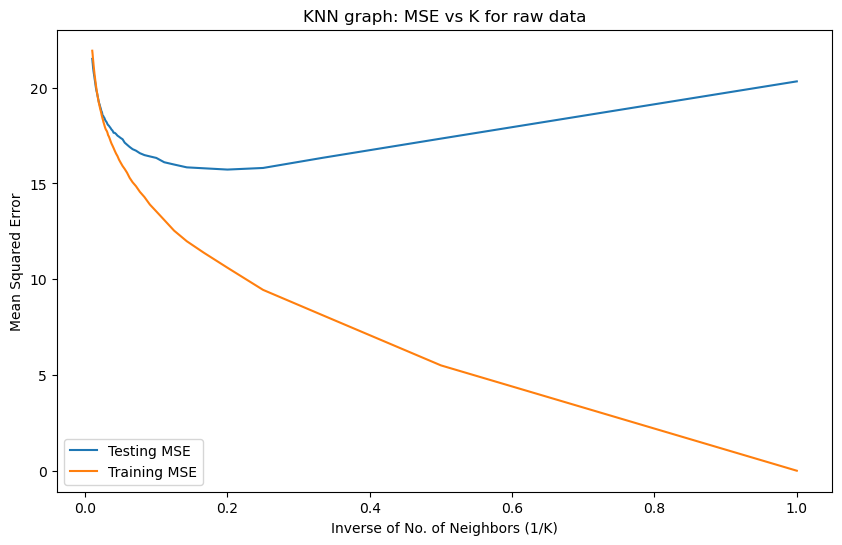

Minimum training error for scaled data: 0.0
Minimum testing error for scaled data: 14.291333431295715
Optimal K value (min test error) k* for scaled data: 4


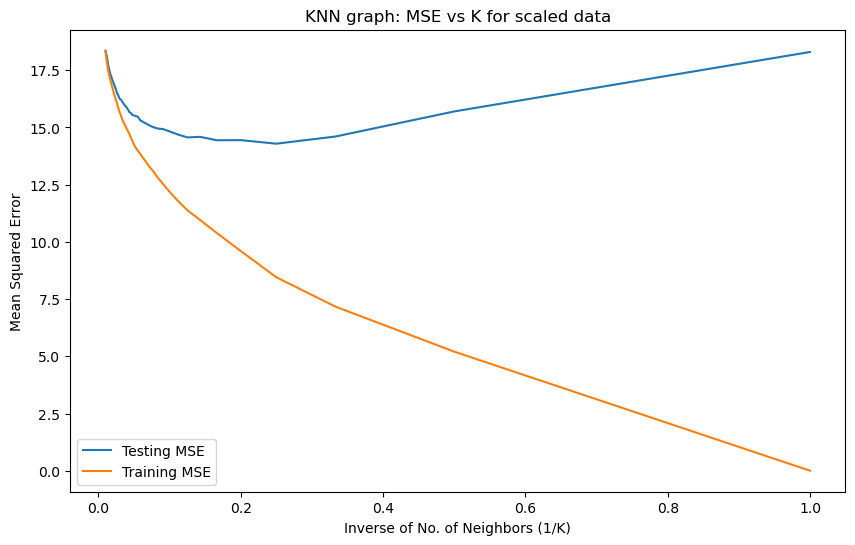

In [16]:
def knn_model(x_train, x_test, y_train, y_test, k_values, scaled=False):
    k_inv_values = [1/k for k in k_values]
    if scaled:
        s = "scaled"    
    else:
        s = "raw"
    train_mse_val = []
    test_mse_val = []
    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(x_train, y_train)
        y_test_pred_knn = knn.predict(x_test)
        y_train_predict_knn = knn.predict(x_train)
        train_mse_val.append(mean_squared_error(y_train, y_train_predict_knn))
        test_mse_val.append(mean_squared_error(y_test, y_test_pred_knn))
        
    print("Minimum training error for " + s + " data: " + str(min(train_mse_val)))
    print("Minimum testing error for " + s + " data: " + str(min(test_mse_val)))
    final_testing_error_d["KNN with " + s + " data"] = min(test_mse_val)
    print("Optimal K value (min test error) k* for " + s + " data: " + str(k_values[np.argmin(test_mse_val)]))
    plt.figure(figsize=(10, 6))
    plt.plot(k_inv_values, test_mse_val, label='Testing MSE')
    plt.plot(k_inv_values, train_mse_val, label='Training MSE')
    plt.title('KNN graph: MSE vs K for ' + s + ' data')
    plt.xlabel('Inverse of No. of Neighbors (1/K)')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.show()


df1 = df.copy()
x_train = df1.drop(columns=['PE'])
y_train = df1['PE']
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.3, random_state=42)
train_df = x_train.copy()
train_df['PE'] = y_train
test_df = x_test.copy()
test_df['PE'] = y_test
k_values = [i for i in range(1, 101)]
scaler = MinMaxScaler()
x_train_raw = train_df.drop(columns=['PE'])
x_test_raw = test_df.drop(columns=['PE'])
y_train = train_df['PE']
y_test = test_df['PE']
x_train_scaled = scaler.fit_transform(train_df.drop(columns=['PE']))
x_test_scaled = scaler.transform(test_df.drop(columns=['PE']))
knn_model(x_train_raw, x_test_raw, y_train, y_test, k_values, scaled=False)
knn_model(x_train_scaled, x_test_scaled, y_train, y_test, k_values, scaled=True)



### (j ) Compare KNN and Linear

In [17]:
print(final_testing_error_d)
display(pd.DataFrame.from_dict(final_testing_error_d, orient='index').reset_index().rename(columns={'index': 'Model', 0: 'Testing MSE'}))

{'Linear regression without interactions and non-linear terms': 21.2399, 'Lnear regression with interactions and non-linear terms': 18.7989, 'KNN with raw data': 15.726819842563568, 'KNN with scaled data': 14.291333431295715}


,Model,Testing MSE
0,Linear regression without interactions and non...,21.239900
1,Lnear regression with interactions and non-lin...,18.798900
2,KNN with raw data,15.726820
3,KNN with scaled data,14.291333


We observe that KNN after normalization of data gives the best performance i.e. least testing MSE. Also, KNNs on a whole perform better thn Linear regression for this task. This may be because KNNs help capture non-linear representation better than Linear Regression even with interaction and non-linear terms. 

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Flexible method would perform better because there is a lower chance of overfitting, and it can capture non-linearity better than inflexible model.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Inflexible method would be better as the dataset is small and may cause overfitting on the flexible model.

### (c) The relationship between the predictors and response is highly non-linear.

Flexible method is better as it can capture non-linearity and complexities in data better than an inflexible model

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Inflexible method is better as it risks high bias to counteract the high-variance and prevents oveerfitting in the bias-variance tradeoff. 

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [18]:
df3 = pd.DataFrame({'Obs': [1, 2, 3, 4, 5, 6],
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, -1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']})
display(df3)

,Obs,X1,X2,X3,Y
0,1,0,3,0,Red
1,2,2,0,0,Red
2,3,0,1,3,Red
3,4,0,1,2,Green
4,5,-1,0,1,Green
5,6,1,-1,1,Red


In [19]:
data_points = (df3[['X1', 'X2', 'X3']].values.tolist())
origin = [0, 0, 0]
distances = euclidean_distances(data_points, [origin]).flatten()
df3['Distance_from_Origin'] = distances
display(df3)

,Obs,X1,X2,X3,Y,Distance_from_Origin
0,1,0,3,0,Red,3.000000
1,2,2,0,0,Red,2.000000
2,3,0,1,3,Red,3.162278
3,4,0,1,2,Green,2.236068
4,5,-1,0,1,Green,1.414214
5,6,1,-1,1,Red,1.732051


### (b) What is our prediction with K = 1? Why?

Green - as the shortest distance from the origin is 1.414 and the class is Green.

In [20]:
l1 = (df3[['Y', 'Distance_from_Origin']].values.tolist())
l1.sort(key = lambda x:x[1])
print(l1[0][0] + " is the class of the point closest to the origin (0, 0, 0) with a distance of " + str(l1[0][1]))

Green is the class of the point closest to the origin (0, 0, 0) with a distance of 1.4142135623730951


### (c) What is our prediction with K = 3? Why?

In [21]:
l2 = [i[0] for i in l1[:3]]
print(statistics.mode(l2))

Red


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

A Smaller K would be more ideal as it can help the model follow the intricate, complex shape rather than alarge K smoothing the boundary out. Smaller K can capture more detail and has more flexibility.

-------------------------------------------------------------------------------------------

References:-

https://stackoverflow.com/questions/16888888/how-to-read-a-xlsx-file-using-the-pandas-library-in-ipython


https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html


https://www.analyticsvidhya.com/blog/2024/02/pair-plots-in-machine-learning/


https://medium.com/latinxinai/mastering-linear-regression-with-statsmodels-95233a2a602e


https://www.geeksforgeeks.org/python/linear-regression-in-python-using-statsmodels/


https://blog.princehonest.com/stat-learning/ch3/applied.html


https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn


https://www.datarobot.com/blog/multiple-regression-using-statsmodels/




AI PROMPTS:-

Code clean-up, fix errors, optimization

Explanation of simple regression with non-linear and interaction terms.

Make code reusable 





